# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the **Global Economic Stress Dataset**.

## Objectives
- Understand dataset structure
- Identify missing values and anomalies
- Explore relationships between variables
- Generate insights for feature engineering and modeling

In [1]:
!pip install pandas matplotlib seaborn

You should consider upgrading via the '/Users/mcbook/Desktop/global-economic-stress-mlops/venv/bin/python3 -m pip install --upgrade pip' command.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [7]:
pd.__version__

'3.0.1'

In [10]:
df = pd.read_csv("../data/processed/usa_macro_quarterly.csv")

df.head()

,date,gdp_growth,inflation,unemployment,yield_spread,recession
0,2000-01-01,0.36279,3.25779,4.0,0.95,0.0
1,2000-04-01,1.82129,3.29383,3.9,0.47,0.0
2,2000-07-01,0.10193,3.46890,4.0,-0.13,0.0
3,2000-10-01,0.59704,3.44350,3.9,-0.45,0.0
4,2001-01-01,-0.32780,3.40976,4.2,0.22,0.0


In [11]:
df.shape

(100, 6)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          100 non-null    str    
 1   gdp_growth    100 non-null    float64
 2   inflation     100 non-null    float64
 3   unemployment  100 non-null    float64
 4   yield_spread  100 non-null    float64
 5   recession     100 non-null    float64
dtypes: float64(5), str(1)
memory usage: 4.8 KB


In [14]:
df.describe()

,gdp_growth,inflation,unemployment,yield_spread,recession
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.543392,2.578455,5.688000,1.481200,0.110000
std,1.265176,1.734103,1.955478,1.283387,0.314466
min,-7.876780,-1.606960,3.500000,-1.470000,0.000000
25%,0.294325,1.621465,4.200000,0.462500,0.000000
50%,0.616060,2.232755,5.100000,1.620000,0.000000
75%,0.862523,3.341273,6.325000,2.582500,0.000000
max,7.762280,8.584980,13.000000,3.610000,1.000000


In [15]:
df.isna().sum()

date            0
gdp_growth      0
inflation       0
unemployment    0
yield_spread    0
recession       0
dtype: int64

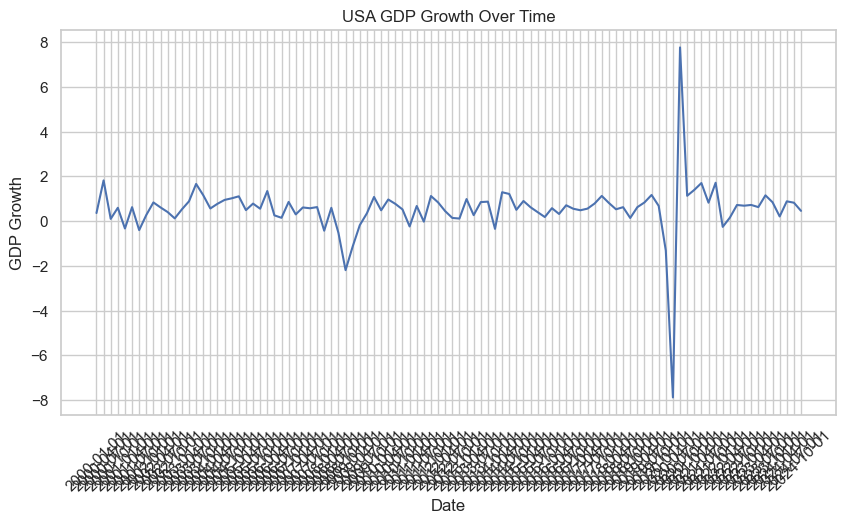

In [20]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["gdp_growth"])

plt.title("USA GDP Growth Over Time")
plt.xlabel("Date")
plt.ylabel("GDP Growth")

plt.xticks(rotation=45)

plt.show()

This shows **economic expansion and contraction periods**.

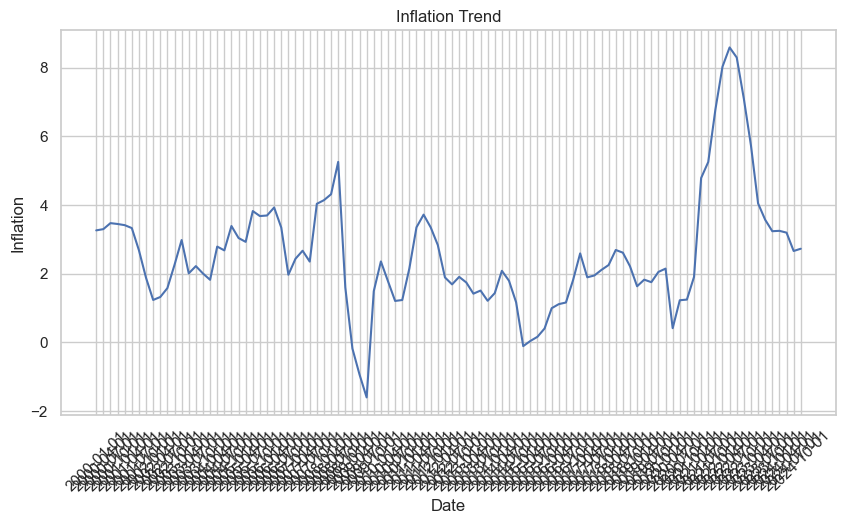

In [21]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["inflation"])

plt.title("Inflation Trend")
plt.xlabel("Date")
plt.ylabel("Inflation")

plt.xticks(rotation=45)

plt.show()

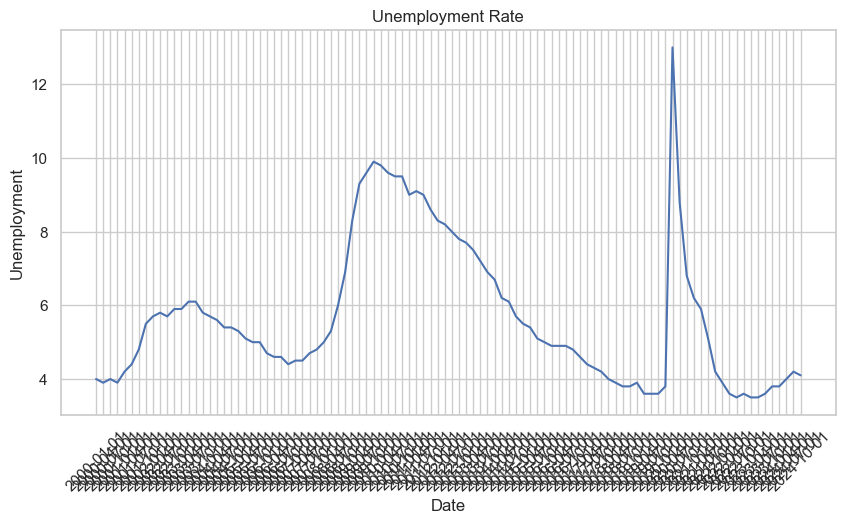

In [23]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["unemployment"])

plt.title("Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment")

plt.xticks(rotation=45)

plt.show()

Unemployment usually **rises during recessions**.

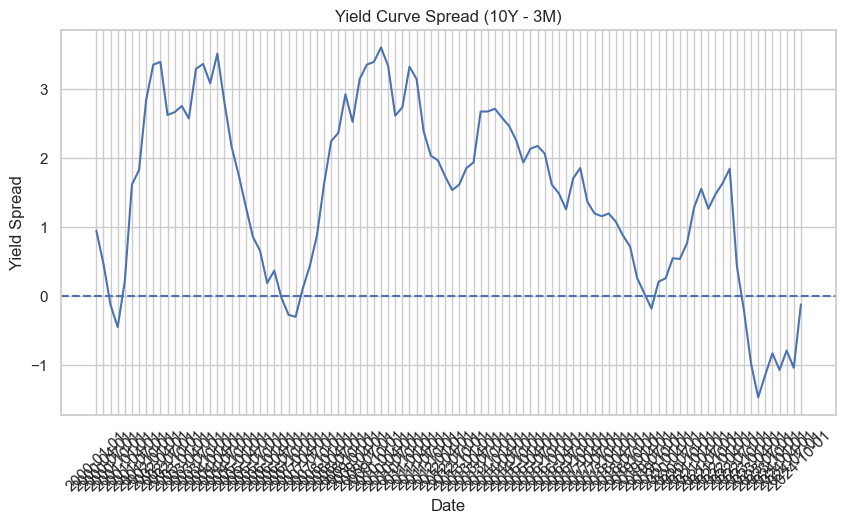

In [24]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["yield_spread"])

plt.axhline(0, linestyle="--")

plt.title("Yield Curve Spread (10Y - 3M)")
plt.xlabel("Date")
plt.ylabel("Yield Spread")

plt.xticks(rotation=45)

plt.show()

When spread goes **below 0**, it's **yield curve inversion**.

This is one of the **best recession signals**.

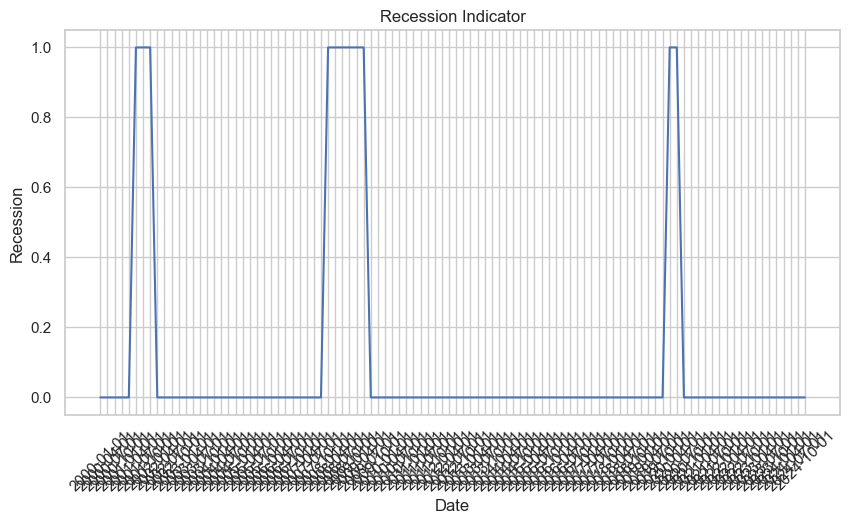

In [25]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["recession"])

plt.title("Recession Indicator")
plt.xlabel("Date")
plt.ylabel("Recession")

plt.xticks(rotation=45)

plt.show()

Shows where recession periods occur.

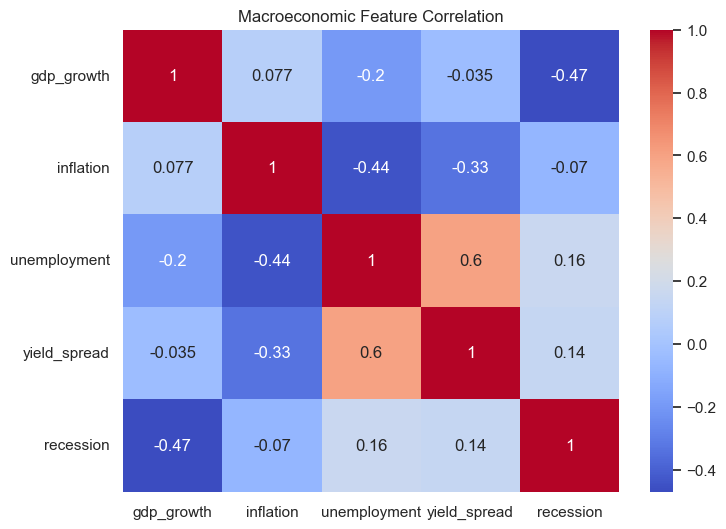

In [26]:
corr = df.drop(columns=["date"]).corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Macroeconomic Feature Correlation")

plt.show()

## Key Observations
- GDP growth declines during recession periods.
- Unemployment increases during economic downturns.
- Yield curve inversion often precedes recessions.
- Macroeconomic indicators show strong relationships with recession periods.

These insights support using these indicators for machine learning recession prediction.